In [10]:
import pandas as pd
import matplotlib.pyplot as plt



In [11]:
df = pd.read_excel("../data/Folds5x2_pp.xlsx")

In [12]:
df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [13]:
for col in df.columns:
    df.rename(columns={col: col.replace(" ", "").lower()}, inplace=True)
df



,at,v,ap,rh,pe
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


In [14]:
target = "pe"
control_variables = ["at", "v"]
features = list(df.columns)
features.remove(target)


print("features: ", features)
print("control_variables: ", control_variables)
print("target: ", target)


features:  ['at', 'v', 'ap', 'rh']
control_variables:  ['at', 'v']
target:  pe


In [15]:
df.to_csv("../data/data_energy.csv", index=False)


In [16]:
df

,at,v,ap,rh,pe
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


# Action Space

In this case the action space will be all features availables


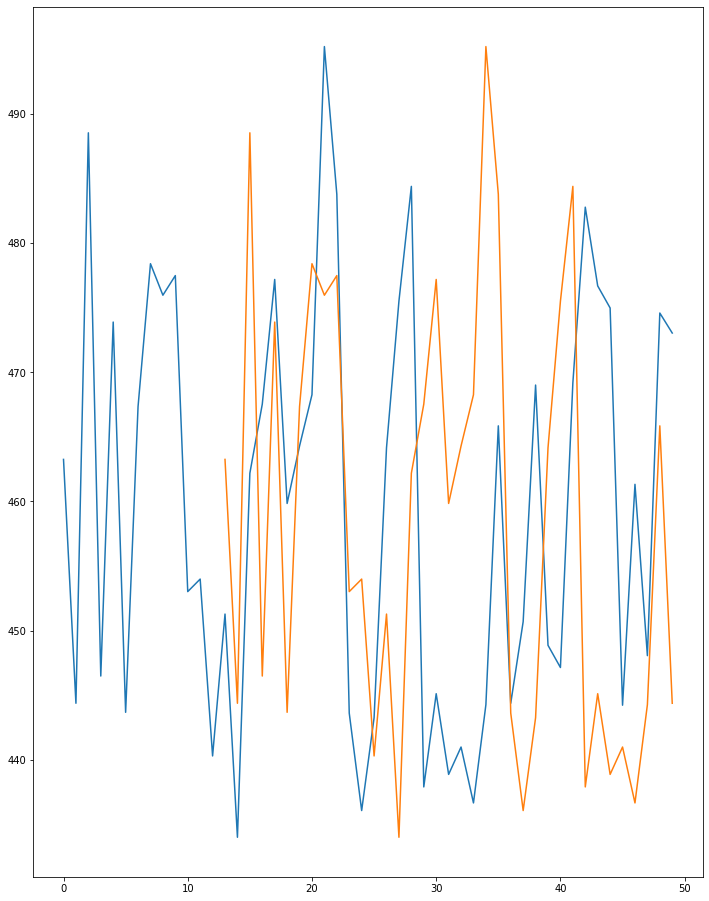

In [17]:
fig = plt.figure(figsize=(12, 16))
df["pe"].iloc[0: 50].plot()
df["pe"].shift(13).iloc[0: 50].plot()
plt.show()


In [20]:
df["pe_lagged_1"] = df["pe"].shift(1)
df

,at,v,ap,rh,pe,pe_lagged_1
0,14.96,41.76,1024.07,73.17,463.26,NaN
1,25.18,62.96,1020.04,59.08,444.37,463.26
2,5.11,39.40,1012.16,92.14,488.56,444.37
3,20.86,57.32,1010.24,76.64,446.48,488.56
4,10.82,37.50,1009.23,96.62,473.90,446.48
...,...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03,467.32
9564,13.19,39.18,1023.67,66.78,469.62,460.03
9565,31.32,74.33,1012.92,36.48,429.57,469.62
9566,24.48,69.45,1013.86,62.39,435.74,429.57


In [21]:
df.dropna().corr()

,at,v,ap,rh,pe,pe_lagged_1
at,1.000000,0.844102,-0.507528,-0.542547,-0.948127,0.002480
v,0.844102,1.000000,-0.413407,-0.312204,-0.869783,0.002952
ap,-0.507528,-0.413407,1.000000,0.099593,0.518427,-0.000783
rh,-0.542547,-0.312204,0.099593,1.000000,0.389800,0.002674
pe,-0.948127,-0.869783,0.518427,0.389800,1.000000,-0.004973
pe_lagged_1,0.002480,0.002952,-0.000783,0.002674,-0.004973,1.000000
